In [1]:
# Cell 1 — Mount Drive + imports
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

BASE    = "/content/drive/MyDrive/EyeMotionID"
PLOTS   = os.path.join(BASE, "results/plots")
REPORTS = os.path.join(BASE, "results/reports")
os.makedirs(PLOTS,   exist_ok=True)
os.makedirs(REPORTS, exist_ok=True)

print("✓ Drive mounted")
print("✓ Plots path  :", os.path.exists(PLOTS))
print("✓ Reports path:", os.path.exists(REPORTS))

Mounted at /content/drive
✓ Drive mounted
✓ Plots path  : True
✓ Reports path: True


##Project timeline visualization

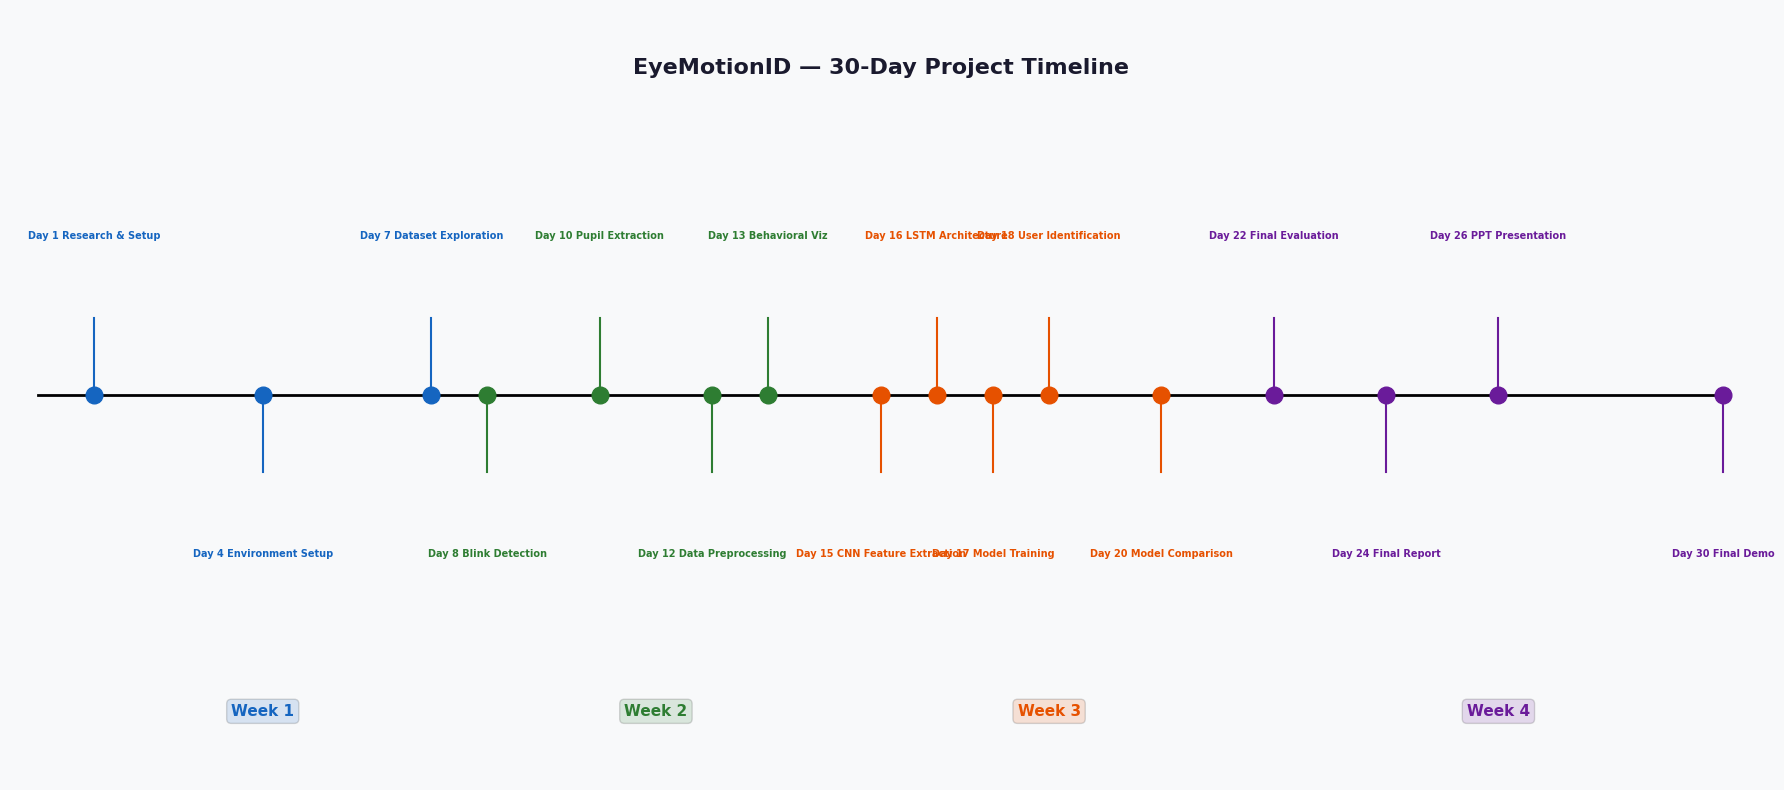

✓ Saved → results/plots/project_timeline.png


In [4]:
fig, ax = plt.subplots(figsize=(18, 8))
ax.set_xlim(-0.5, 30.5)
ax.set_ylim(-2, 4)
ax.axis('off')
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

ax.text(15, 3.5, "EyeMotionID — 30-Day Project Timeline",
        ha='center', fontsize=16, fontweight='bold', color='#1A1A2E')

# week colors
week_colors = {
    'Week 1': '#1565C0',
    'Week 2': '#2E7D32',
    'Week 3': '#E65100',
    'Week 4': '#6A1B9A'
}

# draw timeline line
ax.plot([0, 30], [1, 1], 'k-', linewidth=2, zorder=1)

# milestones
milestones = [
    (1,  'Week 1', 'Research & Setup',           '#1565C0'),
    (4,  'Week 1', 'Environment Setup',           '#1565C0'),
    (7,  'Week 1', 'Dataset Exploration',         '#1565C0'),
    (8,  'Week 2', 'Blink Detection',             '#2E7D32'),
    (10, 'Week 2', 'Pupil Extraction',            '#2E7D32'),
    (12, 'Week 2', 'Data Preprocessing',          '#2E7D32'),
    (13, 'Week 2', 'Behavioral Viz',              '#2E7D32'),
    (15, 'Week 3', 'CNN Feature Extraction',      '#E65100'),
    (16, 'Week 3', 'LSTM Architecture',           '#E65100'),
    (17, 'Week 3', 'Model Training',              '#E65100'),
    (18, 'Week 3', 'User Identification',         '#E65100'),
    (20, 'Week 3', 'Model Comparison',            '#E65100'),
    (22, 'Week 4', 'Final Evaluation',            '#6A1B9A'),
    (24, 'Week 4', 'Final Report',                '#6A1B9A'),
    (26, 'Week 4', 'PPT Presentation',            '#6A1B9A'),
    (30, 'Week 4', 'Final Demo',                  '#6A1B9A'),
]

for i, (day, week, label, color) in enumerate(milestones):
    above = i % 2 == 0
    y_dot = 1
    y_text = 2.2 if above else -0.2
    y_line_end = 1.6 if above else 0.4

    ax.plot(day, y_dot, 'o', markersize=12, color=color, zorder=3)
    ax.plot([day, day], [y_dot, y_line_end], '-', color=color, linewidth=1.5, zorder=2)
    ax.text(day, y_text, f"Day {day} {label}",
            ha='center', va='bottom' if above else 'top',
            fontsize=7, color=color, fontweight='bold')

# week labels
for week, x, color in [('Week 1',4,'#1565C0'),('Week 2',11,'#2E7D32'),
                         ('Week 3',18,'#E65100'),('Week 4',26,'#6A1B9A')]:
    ax.text(x, -1.5, week, ha='center', fontsize=11,
            fontweight='bold', color=color,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.15))

plt.tight_layout()
plt.savefig(f"{PLOTS}/project_timeline.png", dpi=100, bbox_inches='tight')
plt.show()
print("✓ Saved → results/plots/project_timeline.png")

##Complete behavioral analysis dashboard

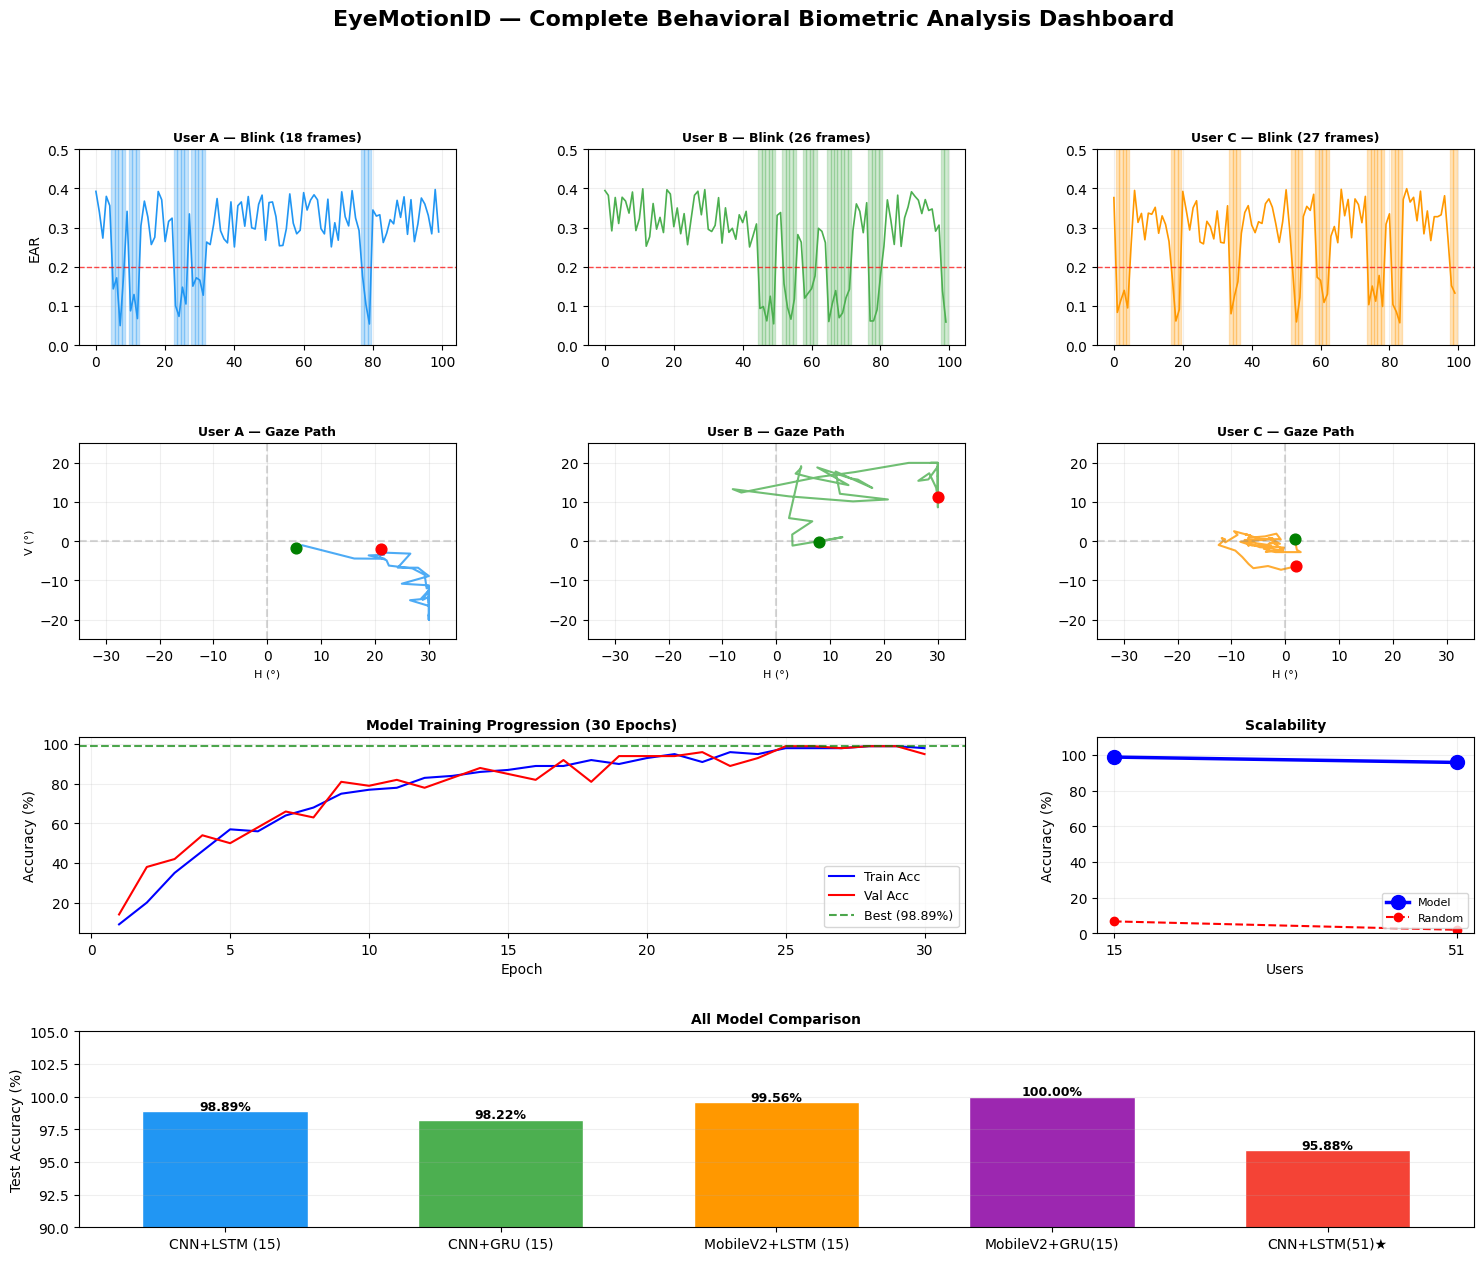

✓ Saved → results/plots/complete_dashboard.png


In [6]:
np.random.seed(42)
FRAMES = 100
USERS  = ["User A", "User B", "User C"]
COLORS = ["#2196F3", "#4CAF50", "#FF9800"]

fig = plt.figure(figsize=(18, 14))
fig.suptitle("EyeMotionID — Complete Behavioral Biometric Analysis Dashboard",
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.5, wspace=0.35)

# Row 1 — Blink timelines
all_ear = []
blink_rates = [0.04, 0.07, 0.10]
for idx, (user, rate, color) in enumerate(zip(USERS, blink_rates, COLORS)):
    ax = fig.add_subplot(gs[0, idx])
    ear_vals = []
    i = 0
    while i < FRAMES:
        if np.random.random() < rate:
            blen = np.random.randint(3,6)
            for b in range(blen):
                if i+b < FRAMES: ear_vals.append(np.random.uniform(0.05,0.18))
            i += blen
        else:
            ear_vals.append(np.random.uniform(0.25,0.40))
            i += 1
    ear_vals = ear_vals[:FRAMES]
    all_ear.append(ear_vals)
    ax.plot(ear_vals, color=color, linewidth=1.2)
    ax.axhline(y=0.20, color='red', linestyle='--', linewidth=1, alpha=0.7)
    for i, e in enumerate(ear_vals):
        if e < 0.20: ax.axvspan(i-0.5,i+0.5,alpha=0.25,color=color)
    blinks = sum(1 for e in ear_vals if e < 0.20)
    ax.set_title(f"{user} — Blink ({blinks} frames)", fontsize=9, fontweight='bold')
    ax.set_ylim(0, 0.5)
    ax.set_ylabel("EAR" if idx==0 else "")
    ax.grid(True, alpha=0.2)

# Row 2 — Gaze paths
gaze_data = []
variances = [(3,2),(6,4),(2,1)]
for idx, (user, color, (vh,vv)) in enumerate(zip(USERS, COLORS, variances)):
    ax = fig.add_subplot(gs[1, idx])
    np.random.seed(idx*10)
    gh = np.clip(np.cumsum(np.random.normal(0,vh,50)),-30,30)
    gv = np.clip(np.cumsum(np.random.normal(0,vv,50)),-20,20)
    gaze_data.append((gh,gv))
    ax.plot(gh, gv, color=color, linewidth=1.5, alpha=0.8)
    ax.scatter(gh[0], gv[0], color='green', s=60, zorder=5)
    ax.scatter(gh[-1],gv[-1],color='red',   s=60, zorder=5)
    ax.set_xlim(-35,35); ax.set_ylim(-25,25)
    ax.axhline(y=0,color='gray',linestyle='--',alpha=0.3)
    ax.axvline(x=0,color='gray',linestyle='--',alpha=0.3)
    ax.set_title(f"{user} — Gaze Path", fontsize=9, fontweight='bold')
    ax.set_xlabel("H (°)",fontsize=8)
    ax.set_ylabel("V (°)" if idx==0 else "",fontsize=8)
    ax.grid(True, alpha=0.2)

# Row 3 — Model accuracy progression
ax_prog = fig.add_subplot(gs[2, :2])
epochs  = list(range(1,31))
train_acc = [9,20,35,46,57,56,64,68,75,77,78,83,84,86,87,89,89,92,90,93,95,91,96,95,98,98,98,99,99,98]
val_acc   = [14,38,42,54,50,58,66,63,81,79,82,78,83,88,85,82,92,81,94,94,94,96,89,93,99,99,98,99,99,95]
ax_prog.plot(epochs, train_acc, 'b-', linewidth=1.5, label='Train Acc')
ax_prog.plot(epochs, val_acc,   'r-', linewidth=1.5, label='Val Acc')
ax_prog.axhline(y=98.89, color='green', linestyle='--', linewidth=1.5,
                label='Best (98.89%)', alpha=0.7)
ax_prog.set_title("Model Training Progression (30 Epochs)", fontsize=10, fontweight='bold')
ax_prog.set_xlabel("Epoch"); ax_prog.set_ylabel("Accuracy (%)")
ax_prog.legend(fontsize=9); ax_prog.grid(True, alpha=0.2)

# Row 3 — Users vs accuracy
ax_scale = fig.add_subplot(gs[2, 2])
ax_scale.plot([15,51],[98.89,95.88],'b-o',markersize=10,linewidth=2.5,label='Model')
ax_scale.plot([15,51],[6.67,1.96],'r--o',markersize=6,linewidth=1.5,label='Random')
ax_scale.set_title("Scalability", fontsize=10, fontweight='bold')
ax_scale.set_xlabel("Users"); ax_scale.set_ylabel("Accuracy (%)")
ax_scale.set_xticks([15,51]); ax_scale.set_ylim(0,110)
ax_scale.legend(fontsize=8); ax_scale.grid(True,alpha=0.2)

# Row 4 — Model comparison
ax_comp = fig.add_subplot(gs[3, :])
models  = ['CNN+LSTM (15)', 'CNN+GRU (15)', 'MobileV2+LSTM (15)', 'MobileV2+GRU(15)', 'CNN+LSTM(51)★']
accs    = [98.89, 98.22, 99.56, 100.00, 95.88]
cols    = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']
bars    = ax_comp.bar(models, accs, color=cols, edgecolor='white', width=0.6)
ax_comp.set_title("All Model Comparison", fontsize=10, fontweight='bold')
ax_comp.set_ylabel("Test Accuracy (%)")
ax_comp.set_ylim(90, 105)
for bar, acc in zip(bars, accs):
    ax_comp.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.1,
                 f"{acc:.2f}%", ha='center', fontsize=9, fontweight='bold')
ax_comp.grid(True, alpha=0.2, axis='y')

plt.savefig(f"{PLOTS}/complete_dashboard.png", dpi=100, bbox_inches='tight')
plt.show()
print("✓ Saved → results/plots/complete_dashboard.png")

##Dataset statistics dashboard

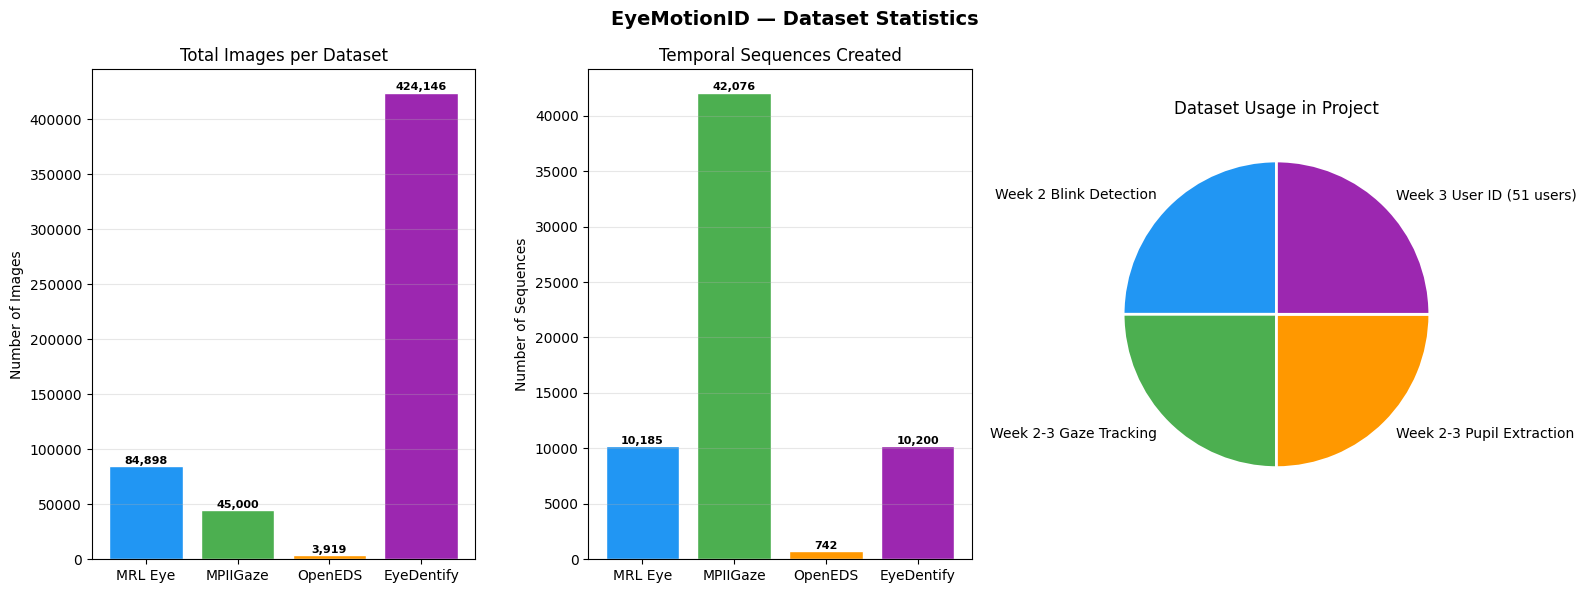

✓ Saved → results/plots/dataset_statistics.png


In [8]:
datasets   = ['MRL Eye', 'MPIIGaze', 'OpenEDS', 'EyeDentify']
images     = [84898, 45000, 3919, 424146]
users      = [None, 15, 27, 51]
sequences  = [10185, 42076, 742, 10200]
colors     = ['#2196F3','#4CAF50','#FF9800','#9C27B0']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("EyeMotionID — Dataset Statistics", fontsize=14, fontweight='bold')

# total images
bars1 = axes[0].bar(datasets, images, color=colors, edgecolor='white')
axes[0].set_title("Total Images per Dataset")
axes[0].set_ylabel("Number of Images")
for bar, val in zip(bars1, images):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+2000,
                 f"{val:,}", ha='center', fontsize=8, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# sequences
bars2 = axes[1].bar(datasets, sequences, color=colors, edgecolor='white')
axes[1].set_title("Temporal Sequences Created")
axes[1].set_ylabel("Number of Sequences")
for bar, val in zip(bars2, sequences):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+200,
                 f"{val:,}", ha='center', fontsize=8, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# usage in project
usage = ['Week 2 Blink Detection','Week 2-3 Gaze Tracking', 'Week 2-3 Pupil Extraction','Week 3 User ID (51 users)']
wedge_colors = colors
axes[2].pie([1,1,1,1], labels=usage, colors=wedge_colors,
            autopct='', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[2].set_title("Dataset Usage in Project")

plt.tight_layout()
plt.savefig(f"{PLOTS}/dataset_statistics.png", dpi=100)
plt.show()
print("✓ Saved → results/plots/dataset_statistics.png")

##Summary

In [10]:
print("=" * 55)
print("   DAY 23 — FINAL VISUALIZATIONS SUMMARY")
print("=" * 55)
print()
print("Visualizations created:")
print("  ✓ Project timeline (30 days)")
print("  ✓ Complete behavioral dashboard")
print("  ✓ Dataset statistics dashboard")
print()
print("Plots saved → results/plots/")
print("  ✓ project_timeline.png")
print("  ✓ complete_dashboard.png")
print("  ✓ dataset_statistics.png")
print()
print("Total plots in project: 30+")
print()
print("Week 4 deliverables status:")
print("  ✅ Behavioral biometric analysis graphs")
print("  ✅ Experimental evaluation plots")
print("  ⏳ Experimental evaluation report (Day 24)")
print("  ⏳ GitHub repository update (Day 25)")
print("  ⏳ PPT presentation (Day 26)")
print("  ⏳ Final demo (Day 30)")
print()
print("=" * 55)

   DAY 23 — FINAL VISUALIZATIONS SUMMARY

Visualizations created:
  ✓ Project timeline (30 days)
  ✓ Complete behavioral dashboard
  ✓ Dataset statistics dashboard

Plots saved → results/plots/
  ✓ project_timeline.png
  ✓ complete_dashboard.png
  ✓ dataset_statistics.png

Total plots in project: 30+

Week 4 deliverables status:
  ✅ Behavioral biometric analysis graphs
  ✅ Experimental evaluation plots
  ⏳ Experimental evaluation report (Day 24)
  ⏳ GitHub repository update (Day 25)
  ⏳ PPT presentation (Day 26)
  ⏳ Final demo (Day 30)

